<a href="https://colab.research.google.com/github/dewshishir/S_M/blob/main/Skill_Morph_Deep_Learning_and_Perceptron_Lecture_14_Data_Science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📚 Lecture #14: Deep Learning and Perceptron

**Instructor:** Md. Samiul Islam  
**Institution:** Skill Morph Research Lab  


---

## 📋 Topics Covered

1. Deep Learning vs Traditional ML
2. How Perceptron Works
3. Activation Functions
4. Batch GD vs Stochastic GD
5. Practice with Iris Dataset
6. Homework Assignment

---

## Part 1: Deep Learning vs Traditional ML

### Key Differences

| Aspect | Traditional ML | Deep Learning |
|--------|---------------|---------------|
| Features | Manual (we create them) | Automatic (model learns them) |
| Data Needed | Small datasets work | Needs large datasets |
| Training Time | Fast | Slow |
| Accuracy | Plateaus with more data | Improves with more data |

### Example: Image Recognition
- **Traditional ML:** We manually extract features (edges, colors) → Feed to classifier
- **Deep Learning:** Raw pixels → Neural network learns features automatically

> 💡 **Perceptron = Simplest neural network unit (a single neuron)**

---
## Part 2: How Perceptron Works

### Perceptron Formula
```
z = w₁×x₁ + w₂×x₂ + ... + wₙ×xₙ + b
y = activation(z)
```

**Components:**
- **x (inputs)** — Your data features
- **w (weights)** — Importance of each feature (learned by model)
- **b (bias)** — Shifts the decision boundary
- **activation** — Transforms the output (adds non-linearity)

### Why Activation Functions?
They add **non-linearity**, helping the model learn complex patterns that a straight line cannot capture.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Two most commonly used activation functions

def sigmoid(z):
    """Squashes output to range (0, 1) — used for binary classification."""
    return 1 / (1 + np.exp(-z))

def relu(z):
    """Passes positive values, zeros out negatives — widely used in deep networks."""
    return np.maximum(0, z)

print("✅ Activation functions defined!")

✅ Activation functions defined!


---
## Part 3: Batch vs Stochastic Gradient Descent

### Gradient Descent = The Learning Algorithm

**Weight update rule:**
```
w = w - learning_rate × gradient
```

### Two Main Types

| Method | Data Used Per Update | Advantages | Disadvantages |
|--------|----------------------|------------|---------------|
| **Batch GD** | All training data | Stable, smooth convergence | Slow, high memory usage |
| **Stochastic GD** | One sample at a time | Fast, can escape local minima | Noisy, less stable |

---
## Part 4: Simple Perceptron Implementation

Let's build a Perceptron **from scratch** — both Batch GD and Stochastic GD modes in one class.

In [ ]:
class Perceptron:
    def __init__(self, lr=0.01, epochs=100, mode='batch'):
        """
        lr     : learning rate
        epochs : number of training passes
        mode   : 'batch' or 'stochastic'
        """
        self.lr     = lr
        self.epochs = epochs
        self.mode   = mode
        self.w      = None
        self.b      = None

    def _sigmoid(self, z):
        """Numerically stable sigmoid."""
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        n, d   = X.shape
        self.w = np.zeros(d)
        self.b = 0

        for epoch in range(self.epochs):
            if self.mode == 'batch':
                # Update using ALL samples at once
                z    = X.dot(self.w) + self.b
                pred = self._sigmoid(z)
                self.w -= self.lr * X.T.dot(pred - y) / n
                self.b -= self.lr * (pred - y).mean()
            else:
                # Update ONE sample at a time
                for i in range(n):
                    z    = X[i].dot(self.w) + self.b
                    pred = self._sigmoid(z)
                    self.w -= self.lr * (pred - y[i]) * X[i]
                    self.b -= self.lr * (pred - y[i])

    def predict(self, X):
        return (self._sigmoid(X.dot(self.w) + self.b) >= 0.5).astype(int)


print("✅ Perceptron class defined!")

✅ Perceptron class defined!


---
## Part 5: Practice with Iris Dataset

### Task: Binary Classification — Setosa vs Others

The Iris dataset has 3 flower classes (150 samples). We simplify it to a **binary problem**:  
- Class 1 → Setosa  
- Class 0 → Everything else

**Kaggle Link:** https://www.kaggle.com/datasets/uciml/iris

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# Load dataset
iris = load_iris()
X    = iris.data
y    = (iris.target == 0).astype(int)  # 1 = Setosa, 0 = Others

print(f"Total samples: {len(X)}")
print(f"Setosa: {sum(y)}, Others: {len(y) - sum(y)}")

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=20
)

# Standardize features (important for gradient-based methods!)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("\n✅ Data ready!")

Total samples: 150
Setosa: 50, Others: 100

✅ Data ready!


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# ── Train with Batch Gradient Descent ──
print("=" * 50)
print("Training with BATCH Gradient Descent")
print("=" * 50)

model_batch   = Perceptron(lr=0.1, epochs=200, mode='batch')
model_batch.fit(X_train, y_train)

y_pred_batch = model_batch.predict(X_test)
acc_batch    = accuracy_score(y_test, y_pred_batch)
prec_batch   = precision_score(y_test, y_pred_batch)
rec_batch    = recall_score(y_test, y_pred_batch)
f1_batch     = f1_score(y_test, y_pred_batch)

print(f"\nTest Accuracy : {acc_batch  * 100:.2f}%")
print(f"Precision     : {prec_batch  * 100:.2f}%")
print(f"Recall        : {rec_batch   * 100:.2f}%")
print(f"F1-Score      : {f1_batch    * 100:.2f}%")
print(f"\nCorrect: {sum(y_pred_batch == y_test)}/{len(y_test)}")

Training with BATCH Gradient Descent

Test Accuracy : 100.00%
Precision     : 100.00%
Recall        : 100.00%
F1-Score      : 100.00%

Correct: 30/30


In [ ]:
# ── Train with Stochastic Gradient Descent ──
print("=" * 50)
print("Training with STOCHASTIC Gradient Descent")
print("=" * 50)

model_sgd   = Perceptron(lr=0.01, epochs=200, mode='stochastic')
model_sgd.fit(X_train, y_train)

y_pred_sgd = model_sgd.predict(X_test)
acc_sgd    = accuracy_score(y_test, y_pred_sgd)
prec_sgd   = precision_score(y_test, y_pred_sgd)
rec_sgd    = recall_score(y_test, y_pred_sgd)
f1_sgd     = f1_score(y_test, y_pred_sgd)

print(f"\nTest Accuracy : {acc_sgd  * 100:.2f}%")
print(f"Precision     : {prec_sgd  * 100:.2f}%")
print(f"Recall        : {rec_sgd   * 100:.2f}%")
print(f"F1-Score      : {f1_sgd    * 100:.2f}%")
print(f"\nCorrect: {sum(y_pred_sgd == y_test)}/{len(y_test)}")

Training with STOCHASTIC Gradient Descent

Test Accuracy : 100.00%
Precision     : 100.00%
Recall        : 100.00%
F1-Score      : 100.00%

Correct: 30/30


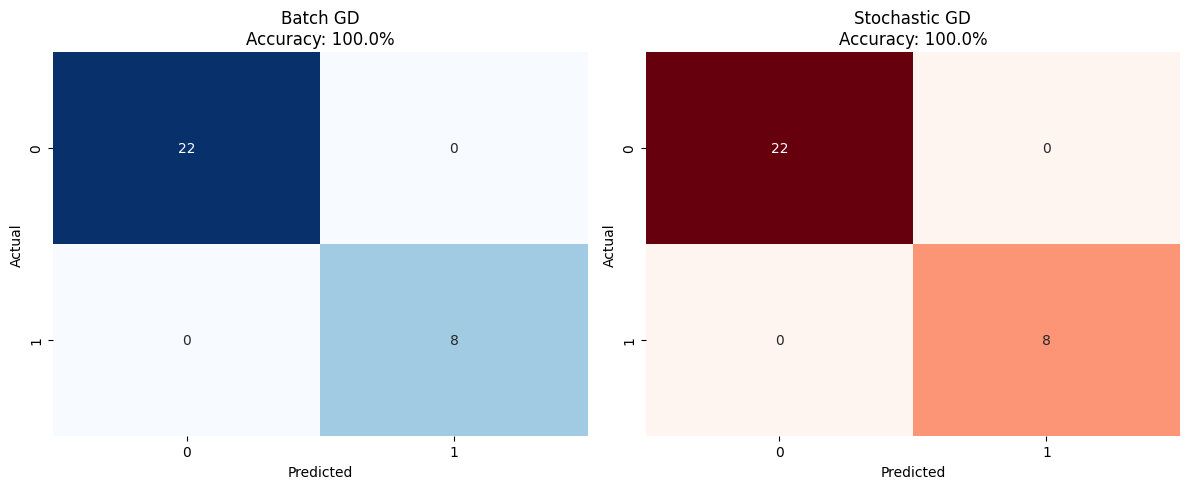


COMPARISON: Batch GD vs Stochastic GD
Metric                           Batch GD        Stochastic GD
----------------------------------------------------------------------
Accuracy                          100.00%              100.00%
Precision                         100.00%              100.00%
Recall                            100.00%              100.00%
F1-Score                          100.00%              100.00%
✅ Training complete!


In [ ]:
# ── Visualize: Confusion Matrices side by side ──

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_batch = confusion_matrix(y_test, y_pred_batch)
sns.heatmap(cm_batch, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title(f'Batch GD\nAccuracy: {acc_batch * 100:.1f}%', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_sgd = confusion_matrix(y_test, y_pred_sgd)
sns.heatmap(cm_sgd, annot=True, fmt='d', cmap='Reds', ax=axes[1], cbar=False)
axes[1].set_title(f'Stochastic GD\nAccuracy: {acc_sgd * 100:.1f}%', fontsize=12)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ── Print comparison table ──
print("\n" + "=" * 70)
print("COMPARISON: Batch GD vs Stochastic GD")
print("=" * 70)
print(f"{'Metric':<20} {'Batch GD':>20} {'Stochastic GD':>20}")
print("-" * 70)
print(f"{'Accuracy':<20} {acc_batch  * 100:>19.2f}% {acc_sgd  * 100:>19.2f}%")
print(f"{'Precision':<20} {prec_batch * 100:>19.2f}% {prec_sgd * 100:>19.2f}%")
print(f"{'Recall':<20} {rec_batch  * 100:>19.2f}% {rec_sgd  * 100:>19.2f}%")
print(f"{'F1-Score':<20} {f1_batch   * 100:>19.2f}% {f1_sgd   * 100:>19.2f}%")
print("=" * 70)
print("✅ Training complete!")
print("=" * 70)

---
## Key Observations

### Batch GD
- **Stable** training — gradients are averaged over all data
- **Predictable** convergence — smooth loss curve
- **Slower** per epoch — processes all data before updating

### Stochastic GD
- **Fast** per update — one sample at a time
- Can **escape local minima** due to noisy updates
- **Noisier** convergence — zigzags toward the minimum

---

### Understanding the Metrics

> **Why not just use Accuracy?**  
> Accuracy can be misleading, especially with **imbalanced data**!

| Metric | Formula | Meaning |
|--------|---------|----------|
| **Precision** | `TP / (TP + FP)` | Of all predicted positives, how many are correct? |
| **Recall** | `TP / (TP + FN)` | Of all actual positives, how many did we catch? |
| **F1-Score** | `2 × (P × R) / (P + R)` | Harmonic mean of Precision and Recall |

---
## 📝 Homework Assignment

### Task: Credit Card Fraud Detection

**Dataset:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

---

### Instructions:

1. **Load and explore the dataset**
   - Check class imbalance (fraud cases are very rare — less than 0.2%!)

2. **Prepare data**
   - Handle any missing values
   - Standardize features (same as we did above)

3. **Train two models**
   - One with Batch GD
   - One with Stochastic GD

4. **Compare results:**
   - Which method converges faster?
   - Accuracy, Precision, Recall, F1-Score?

5. **Answer:** Why is Recall especially important for fraud detection?

---

### Submit:
- Your `.ipynb` file with all outputs
- Written answer to question 5 (2–3 sentences)

In [2]:
# ============================================================
# HOMEWORK TEMPLATE — COMPLETE THE CODE BELOW
# ============================================================

# Student Name: Monowar Islam
# Date:         7/03/2025

import pandas as pd
import numpy as np

# Step 1: Load data
df = pd.read_csv('/content/creditcard.csv')

print("First rows of dataset:")
print(df.head())

print("\nClass distribution:")
print(df['Class'].value_counts())

# Step 2: Prepare data
X = df.drop('Class', axis=1).values
y = df['Class'].values

# Step 3: Handle class imbalance using undersampling
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_balanced, y_balanced = rus.fit_resample(X, y)

print("\nBalanced class distribution:")
print(pd.Series(y_balanced).value_counts())
df = df.dropna(subset=['Class'])

# Step 4: Standardize features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_balanced = scaler.fit_transform(X_balanced)

# Train / Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42
)

# ============================================================
# Model 1 — Batch Gradient Descent
# ============================================================

from sklearn.linear_model import LogisticRegression

batch_model = LogisticRegression(
    solver='lbfgs',      # batch gradient descent
    max_iter=1000
)

batch_model.fit(X_train, y_train)

batch_pred = batch_model.predict(X_test)

# ============================================================
# Model 2 — Stochastic Gradient Descent
# ============================================================

from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    loss='log_loss',
    max_iter=1000,
    random_state=42
)

sgd_model.fit(X_train, y_train)

sgd_pred = sgd_model.predict(X_test)

# ============================================================
# Evaluation
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\nBatch Gradient Descent Results")
print("Accuracy:", accuracy_score(y_test, batch_pred))
print("Precision:", precision_score(y_test, batch_pred))
print("Recall:", recall_score(y_test, batch_pred))
print("F1 Score:", f1_score(y_test, batch_pred))

print("\nStochastic Gradient Descent Results")
print("Accuracy:", accuracy_score(y_test, sgd_pred))
print("Precision:", precision_score(y_test, sgd_pred))
print("Recall:", recall_score(y_test, sgd_pred))
print("F1 Score:", f1_score(y_test, sgd_pred))

First rows of dataset:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V

Question 5:
Recall is especially important in fraud detection because the cost of missing a fraudulent transaction is very high. If the model predicts a fraud as a normal transaction (false negative), the fraud will go undetected and may cause financial loss. Therefore, maximizing recall ensures that most fraudulent transactions are correctly identified by the system.